# Week 10 - PCA and Dimension Reduction Homework
Execute the below code and answer the following questions. __Do NOT commit the csv file!__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_classification

def generate_data():
    x, y = make_classification(n_samples=1500,
                            n_features = 20,
                            n_informative = 8,
                            n_redundant = 5,
                            n_repeated = 1,
                            n_classes = 3,
                            weights = (0.5, 0.25, 0.25),
                            random_state = 120
                            )
    colNames = ['var'+str(x) for x in range(20)]
    colNames.append('target')

    df = pd.DataFrame(np.concatenate((x,y.reshape(-1,1)), axis=1), columns=colNames)
    df.to_csv('pca-dataset.csv', index=False)

generate_data()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

df = pd.read_csv('pca-dataset.csv')
df.head()

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,var11,var12,var13,var14,var15,var16,var17,var18,var19,target
0,-2.882513,-3.272465,-2.520732,-1.987174,-2.073689,-3.272465,-1.237969,1.690547,-0.211314,-5.753190,...,-0.574979,-1.916275,-5.994075,-3.349615,-0.846193,2.491347,1.360958,-2.892522,-1.377561,0.0
1,0.775242,-1.015994,0.005137,0.057274,0.590205,-1.015994,1.350954,-1.493037,-0.862391,-1.986047,...,0.523760,0.399579,0.088600,0.718606,-1.112030,0.083929,0.606544,-1.376793,1.302641,2.0
2,-0.876376,0.220453,3.114224,-1.640025,1.180348,0.220453,0.465102,0.222511,0.880455,2.922315,...,-0.370516,3.585262,-2.168162,2.693429,-0.966636,1.586302,-2.821546,0.482164,0.187404,0.0
3,-2.550342,-1.968144,0.077681,-1.887719,1.864445,-1.968144,-0.527958,-0.201467,-0.532649,2.287445,...,-0.041341,2.383582,-0.417253,1.305379,-0.435123,-0.468557,0.923290,3.880050,2.676798,1.0
4,-0.454974,1.293300,0.112201,-0.589989,-1.674321,1.293300,0.487302,1.776318,0.702520,-1.024127,...,-0.452869,-0.667306,0.345364,-3.920591,-0.438296,-1.690141,0.176906,1.920142,1.474634,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var0    1500 non-null   float64
 1   var1    1500 non-null   float64
 2   var2    1500 non-null   float64
 3   var3    1500 non-null   float64
 4   var4    1500 non-null   float64
 5   var5    1500 non-null   float64
 6   var6    1500 non-null   float64
 7   var7    1500 non-null   float64
 8   var8    1500 non-null   float64
 9   var9    1500 non-null   float64
 10  var10   1500 non-null   float64
 11  var11   1500 non-null   float64
 12  var12   1500 non-null   float64
 13  var13   1500 non-null   float64
 14  var14   1500 non-null   float64
 15  var15   1500 non-null   float64
 16  var16   1500 non-null   float64
 17  var17   1500 non-null   float64
 18  var18   1500 non-null   float64
 19  var19   1500 non-null   float64
 20  target  1500 non-null   float64
dtypes: float64(21)
memory usage: 246.2 KB

In [4]:
from sklearn.model_selection import train_test_split

X = df[[x for x in df.columns if x.startswith('var')]]
y = df['target']

X_train, X_test, y_training, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')

print('\nFeatures:')
print(*X_train, sep='\t')

Training samples: 1,200
Test samples: 300

Features:
var0	var1	var2	var3	var4	var5	var6	var7	var8	var9	var10	var11	var12	var13	var14	var15	var16	var17	var18	var19


### Data Description
- `var1 - var19`: a feature for the data.  
- `target`: variable we wish to be able to predict, which is 1 of 3 classes.

# Question 1
- Use principle components analysis to determine the number of components to reduce the data to by evaluating the explained variance ratio (use `X_train`).  
- Remember to scale the data first.  
- What number of components would you recommend based on your analysis?  
- Explain your results using markdown cells.

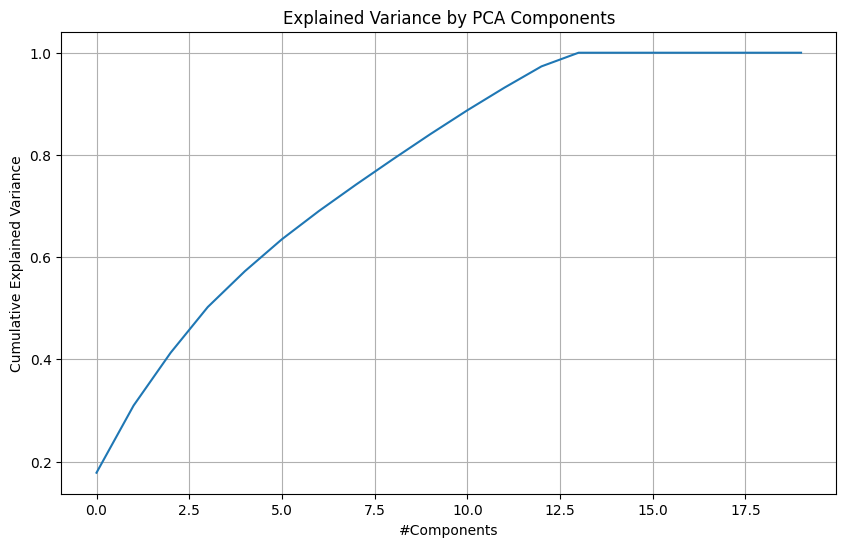

In [5]:
# insert code here
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Applying PCA
pca = PCA()
pca.fit(X_train_scaled)

# Plotting the Explained Variance Ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('#Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()


>
From the above obtained graph of explained variance by pca components, we can use elbow method to find the best number of components. Therefore i would recommend 13 to be best number of parameters to work with

<Insert comments>

# Question 2
- Evaluate the target variable in the `df` object.  
- Which metric would you use in evaluating a predictive model. Explain your choice in the markdown cell.

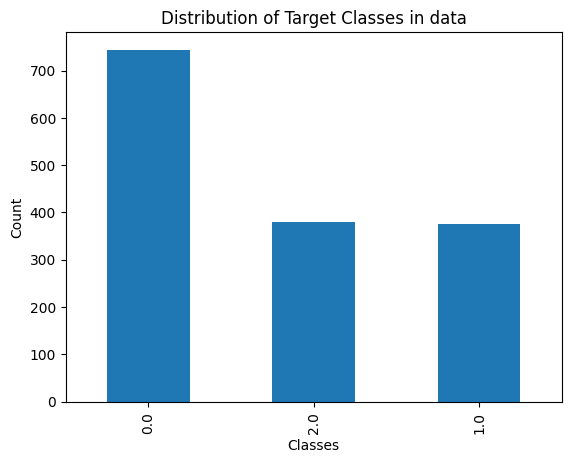

In [6]:
# Insert code here
# Checking the distribution of the target variable
y.value_counts().plot(kind='bar')
plt.title('Distribution of Target Classes in data')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()


> As the classes are unbalanced, i would prefer accuracy as a good metric of evaluation. Accuracy would be a good metric because, it evaluates the model to predict well on all the classes unbiased. Therefore, accuracy would be a good metric.

# Question 3
- Without using PCA, create a logistic regression model using practices discussed in class.  
- Which model would you choose? Explain your results in the markdown cells.    
- What is the accuracy, precision, and recall for the test data?  

In [11]:
# Insert code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

# Hyperparameters to tune
param_grid_lr = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'solver': ['newton-cg', 'lbfgs', 'liblinear']  # Algorithm to use in the optimization problem
}

# Grid Search with cross-validation
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_training)

# Best parameters and best score
print("Best parameters for Logistic Regression:", grid_lr.best_params_)
print("Best score:", grid_lr.best_score_)

# Evaluating the best model on the test data
X_test_scaled = scaler.fit_transform(X_test)
y_pred_lr_grid = grid_lr.predict(X_test_scaled)
print("Accuracy on test data:", accuracy_score(y_test, y_pred_lr_grid))
print("Precision on test data:", precision_score(y_test, y_pred_lr_grid, average='macro'))
print("Recall on test data:", recall_score(y_test, y_pred_lr_grid, average='macro'))


Best parameters for Logistic Regression: {'C': 10, 'solver': 'newton-cg'}
Best score: 0.7216666666666667
Accuracy on test data: 0.7033333333333334
Precision on test data: 0.6862528067332493
Recall on test data: 0.6767589507315535


> The best logistic regression model is obtained from grid search using the best hyper parameters {'C': 10, 'solver': 'newton-cg'}. The accuracy of the model is around 70 percent (0.6966), precision = 0.6798 and recall = 0.6676 for the test dataset

# Question 4
- Use PCA within a pipeline to create a logistic regression model using best practices from class.  
- Which model performs the best on the training data? Explain your results in markdown cells.  
- What is the accuracy, precision, and recall for the test data?
- Does this perform better than the original logistic regression model?

In [13]:
# Insert code
from sklearn.pipeline import Pipeline

# Creating a pipeline with PCA and Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=13)), 
    ('log_reg', LogisticRegression(C=10, solver='newton-cg'))
])

pipeline.fit(X_train, y_training)

#performance fo both models on training data.
Y_train_logreg_pred = grid_lr.predict(X_train_scaled)
Y_train_logreg_pca_pred = pipeline.predict(X_train)

print("accuracy of logistic regression without pca: ", accuracy_score(y_training, Y_train_logreg_pred)) 
print("accuracy of logistic regression with pca: ", accuracy_score(y_training, Y_train_logreg_pca_pred)) 

# Evaluating the model
y_pred_pca = pipeline.predict(X_test)
print("Accuracy on test data (with pca):", accuracy_score(y_test, y_pred_pca))
print("Precision on test data (with pca):", precision_score(y_test, y_pred_pca, average='macro'))
print("Recall on test data (with pca):", recall_score(y_test, y_pred_pca, average='macro'))


accuracy of logistic regression without pca:  0.7258333333333333
accuracy of logistic regression with pca:  0.73
Accuracy on test data (with pca): 0.71
Precision on test data (with pca): 0.6931460944119173
Recall on test data (with pca): 0.6857679597405625


> The model with pca has better accuracy on training data as compared to the model without pca. training accuracy of 0.73 with pca as compared to 0.725 for without pca. On the test data, the model obtains accuracyof 0.71, precison of 0.69 and recall of 0.68. AS the accuracy on test data increased, this model does perform better than the original model without pca.

# Question 5

- Without using PCA, create a decision tree model using best practices discussed in class.  
- Which model performs the best on the training data? Explain your results in the markdown cells.  
- What is the accuracy, precision, and recall for the test data?  
- Does this perform better than either of the logistic regression models?

In [18]:
# Insert code here
from sklearn.tree import DecisionTreeClassifier

# Hyperparameters to tune
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10,15, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with cross-validation
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_scaled, y_training)

# Best parameters and best score
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best score:", grid_dt.best_score_)

#evaluating on training data
y_pred_train_grid_dt = grid_dt.predict(X_train_scaled)
print("Accuracy on training data: ", accuracy_score(y_training, y_pred_train_grid_dt))

# Evaluating the best model on the test data
y_pred_dt_grid = grid_dt.predict(X_test_scaled)
print("Accuracy on test data:", accuracy_score(y_test, y_pred_dt_grid))
print("Precision on test data:", precision_score(y_test, y_pred_dt_grid, average='macro'))
print("Recall on test data:", recall_score(y_test, y_pred_dt_grid, average='macro'))


Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score: 0.7591666666666665
Accuracy on training data:  0.9441666666666667
Accuracy on test data: 0.72
Precision on test data: 0.6986352049219792
Recall on test data: 0.6898546411036338


> The model with the hyper parameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2} does well on training data. On the test data, the model has accuracy of 0.72, precision fo 0.69, and recall of 0.69. This model performs well compared to logistic regression models.

# Question 6
- Repeat `Question 5` but use PCA.  
- Does this perform better than the original Decision Tree or the logistic regression models?

In [20]:
# Insert code here
# Creating a pipeline with PCA and Decision Tree
pipeline_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=13)), 
    ('dtree', DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2))
])

pipeline_tree.fit(X_train, y_training)

#evaluation on training data
y_pred_pca_train = pipeline_tree.predict(X_train)
print("Accuracy on training data: ", accuracy_score(y_training, y_pred_pca_train))

# Evaluation
y_pred_tree_pca = pipeline_tree.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred_tree_pca))
print("Precision on test data:", precision_score(y_test, y_pred_tree_pca, average='macro'))
print("Recall on test data:", recall_score(y_test, y_pred_tree_pca, average='macro'))


Accuracy on training data:  0.9458333333333333
Accuracy on test data: 0.66
Precision on test data: 0.6370152505446622
Recall on test data: 0.6365604121446183


> This model does not perform better than the original decision tree model. or any other logistic regression models.